Le pricing des billets d’avion est un enjeu important pour les compagnies aériennes, 
car les prix varient selon de nombreux facteurs (date, demande, destination,etc). 
Le problème consiste à comprendre ces variations et à prédire le prix des billets. 
Ce projet cherche donc à identifier les facteurs influents et à construire un modèle capable d’estimer les prix.

1-Préparation et prétraitement des données 

In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
data_Train = pd.read_excel("Data_Train.xlsx")
data_Test = pd.read_excel("Test_set.xlsx")
data_prediction_test = pd.read_excel("Sample_submission.xlsx")


In [3]:
data_Train.head(15)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625


In [4]:
# infos du dataset d'entrainement 
data_Train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [5]:
# descriprion ses données d'entrainnement
data_Train.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [6]:
#rechercheons les valeures nulles,
data_Train.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [7]:
data_Train[data_Train.isnull().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [8]:
#drop the nullvalues
data_Train.dropna(inplace=True)

In [9]:
data_Train.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [10]:
def change_into_datetime(col):
    data_Train[col]=pd.to_datetime(data_Train[col])

In [11]:
for i in ['Date_of_Journey','Dep_Time', 'Arrival_Time']:
    change_into_datetime(i)

C:\Users\landr\AppData\Local\Temp\ipykernel_34592\799145402.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data_Train[col]=pd.to_datetime(data_Train[col])
C:\Users\landr\AppData\Local\Temp\ipykernel_34592\799145402.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_Train[col]=pd.to_datetime(data_Train[col])
C:\Users\landr\AppData\Local\Temp\ipykernel_34592\799145402.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_Train[col]=pd.to_datetime(data_Train[col])


In [12]:
data_Train.dtypes

Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Dep_Time           datetime64[ns]
Arrival_Time       datetime64[ns]
Duration                   object
Total_Stops                object
Additional_Info            object
Price                       int64
dtype: object

In [13]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-03-22 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-03-22 05:50:00,2026-03-22 13:15:00,7h 25m,2 stops,No info,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-03-22 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-03-22 18:05:00,2026-03-22 23:30:00,5h 25m,1 stop,No info,6218
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-03-22 16:50:00,2026-03-22 21:35:00,4h 45m,1 stop,No info,13302


In [14]:
data_Train["mois_depart"] = data_Train["Date_of_Journey"].dt.month
data_Train["jour_depart"] = data_Train["Date_of_Journey"].dt.day

In [15]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-03-22 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,3,24
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-03-22 05:50:00,2026-03-22 13:15:00,7h 25m,2 stops,No info,7662,5,1
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-03-22 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,6,9
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-03-22 18:05:00,2026-03-22 23:30:00,5h 25m,1 stop,No info,6218,5,12
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-03-22 16:50:00,2026-03-22 21:35:00,4h 45m,1 stop,No info,13302,3,1


In [16]:
data_Train["Dep_Time"] = data_Train["Dep_Time"].dt.strftime("%H:%M")
data_Train["Arrival_Time"] = data_Train["Arrival_Time"].dt.strftime("%H:%M")

In [17]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,3,24
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,1
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,6,9
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,5,12
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,3,1


In [18]:
def convertion_duree(x):
    x = str(x)
    h = 0
    m = 0

    if "h" in x:
        h = int(x.split("h")[0])

    if "m" in x:
        if "h" in x:
            m = int(x.split("h")[1].replace("m", "").strip())
        else:
            m = int(x.replace("m", ""))

    return h*60 + m

data_Train["duree_min"] = data_Train["Duration"].apply(convertion_duree)

In [19]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,3,24,170
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,1,445
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,6,9,1140
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,5,12,325
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,3,1,285


In [20]:
data_Train["Airline"].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [21]:
data_Train["Route"].value_counts()

Route
DEL → BOM → COK                      2376
BLR → DEL                            1552
CCU → BOM → BLR                       979
CCU → BLR                             724
BOM → HYD                             621
                                     ... 
BOM → VNS → DEL → HYD                   1
BLR → HBX → BOM → NAG → DEL             1
BLR → BOM → IXC → DEL                   1
BLR → CCU → BBI → HYD → VGA → DEL       1
BOM → BBI → HYD                         1
Name: count, Length: 128, dtype: int64

In [22]:
data_Train.drop("Route", axis=1, inplace=True)

In [23]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min
0,IndiGo,2019-03-24,Banglore,New Delhi,22:20,01:10,2h 50m,non-stop,No info,3897,3,24,170
1,Air India,2019-05-01,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,No info,7662,5,1,445
2,Jet Airways,2019-06-09,Delhi,Cochin,09:25,04:25,19h,2 stops,No info,13882,6,9,1140
3,IndiGo,2019-05-12,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,No info,6218,5,12,325
4,IndiGo,2019-03-01,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302,3,1,285


In [24]:
data_Train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Dep_Time         10682 non-null  object        
 5   Arrival_Time     10682 non-null  object        
 6   Duration         10682 non-null  object        
 7   Total_Stops      10682 non-null  object        
 8   Additional_Info  10682 non-null  object        
 9   Price            10682 non-null  int64         
 10  mois_depart      10682 non-null  int32         
 11  jour_depart      10682 non-null  int32         
 12  duree_min        10682 non-null  int64         
dtypes: datetime64[ns](1), int32(2), int64(2), object(8)
memory usage: 1.1+ MB


In [25]:
data_Train["dep_hour"] = data_Train["Dep_Time"].str.split(":").str[0].astype(int)
data_Train["arr_hour"] = data_Train["Arrival_Time"].str.split(":").str[0].astype(int)

In [26]:
def periode_jour(h):
    if h < 6:
        return "nuit"
    elif h < 12:
        return "matin"
    elif h < 18:
        return "apres_midi"
    else:
        return "soir"

data_Train["periode_depart"] = data_Train["dep_hour"].apply(periode_jour)

In [27]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,22:20,01:10,2h 50m,non-stop,No info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,No info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,Delhi,Cochin,09:25,04:25,19h,2 stops,No info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,No info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302,3,1,285,16,21,apres_midi


In [28]:
data_Train["Additional_Info"].value_counts()

Additional_Info
No info                         8344
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [29]:
data_Train["Additional_Info"] = (
    data_Train["Additional_Info"]
    .str.lower()
    .str.strip()
)

In [30]:
data_Train["Additional_Info"].value_counts()

Additional_Info
no info                         8347
in-flight meal not included     1982
no check-in baggage included     320
1 long layover                    19
change airports                    7
business class                     4
1 short layover                    1
red-eye flight                     1
2 long layover                     1
Name: count, dtype: int64

In [31]:
data_Train["Source"] = (
    data_Train["Source"]
    .str.lower()
    .str.strip()
)

In [32]:
data_Train["Destination"] = (
    data_Train["Destination"]
    .str.lower()
    .str.strip()
)

In [33]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,banglore,new delhi,22:20,01:10,2h 50m,non-stop,no info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,kolkata,banglore,05:50,13:15,7h 25m,2 stops,no info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,delhi,cochin,09:25,04:25,19h,2 stops,no info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,kolkata,banglore,18:05,23:30,5h 25m,1 stop,no info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,banglore,new delhi,16:50,21:35,4h 45m,1 stop,no info,13302,3,1,285,16,21,apres_midi


In [34]:
data_Train["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [35]:
data_Train["Total_Stops"] = data_Train["Total_Stops"].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

C:\Users\landr\AppData\Local\Temp\ipykernel_34592\2653556922.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_Train["Total_Stops"] = data_Train["Total_Stops"].replace({


In [36]:
data_Train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Dep_Time         10682 non-null  object        
 5   Arrival_Time     10682 non-null  object        
 6   Duration         10682 non-null  object        
 7   Total_Stops      10682 non-null  int64         
 8   Additional_Info  10682 non-null  object        
 9   Price            10682 non-null  int64         
 10  mois_depart      10682 non-null  int32         
 11  jour_depart      10682 non-null  int32         
 12  duree_min        10682 non-null  int64         
 13  dep_hour         10682 non-null  int64         
 14  arr_hour         10682 non-null  int64     

In [37]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,banglore,new delhi,22:20,01:10,2h 50m,0,no info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,kolkata,banglore,05:50,13:15,7h 25m,2,no info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,delhi,cochin,09:25,04:25,19h,2,no info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,kolkata,banglore,18:05,23:30,5h 25m,1,no info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,banglore,new delhi,16:50,21:35,4h 45m,1,no info,13302,3,1,285,16,21,apres_midi


In [38]:
data_Train["Total_Stops"] = data_Train["Total_Stops"].astype(int)

2- Visualisation des données:
cette approche est utilisé pour:
-comprendre les rélations entre les données et déterminer les données importantes 
-mener des analyse données
-comprendre la répartition des données 

In [39]:
#importation des bibiothèques utiles
import seaborn as sns 
import matplotlib.pyplot as plt

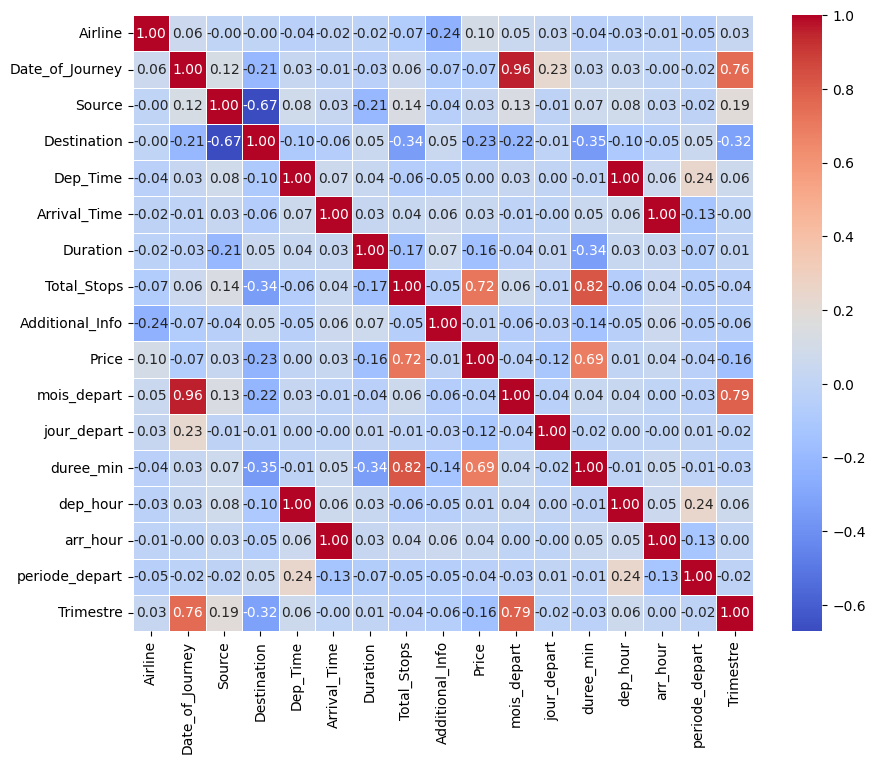

In [40]:
data_Train['Trimestre'] = ((data_Train['mois_depart'] - 1) // 3) + 1
from sklearn.preprocessing import LabelEncoder
plt.figure(figsize=(10, 8))
df_encoded = data_Train.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

corr = df_encoded.corr(method='spearman')

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

In [41]:
data_Train

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart,Trimestre
0,IndiGo,2019-03-24,banglore,new delhi,22:20,01:10,2h 50m,0,no info,3897,3,24,170,22,1,soir,1
1,Air India,2019-05-01,kolkata,banglore,05:50,13:15,7h 25m,2,no info,7662,5,1,445,5,13,nuit,2
2,Jet Airways,2019-06-09,delhi,cochin,09:25,04:25,19h,2,no info,13882,6,9,1140,9,4,matin,2
3,IndiGo,2019-05-12,kolkata,banglore,18:05,23:30,5h 25m,1,no info,6218,5,12,325,18,23,soir,2
4,IndiGo,2019-03-01,banglore,new delhi,16:50,21:35,4h 45m,1,no info,13302,3,1,285,16,21,apres_midi,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,kolkata,banglore,19:55,22:25,2h 30m,0,no info,4107,4,9,150,19,22,soir,2
10679,Air India,2019-04-27,kolkata,banglore,20:45,23:20,2h 35m,0,no info,4145,4,27,155,20,23,soir,2
10680,Jet Airways,2019-04-27,banglore,delhi,08:20,11:20,3h,0,no info,7229,4,27,180,8,11,matin,2
10681,Vistara,2019-03-01,banglore,new delhi,11:30,14:10,2h 40m,0,no info,12648,3,1,160,11,14,matin,1


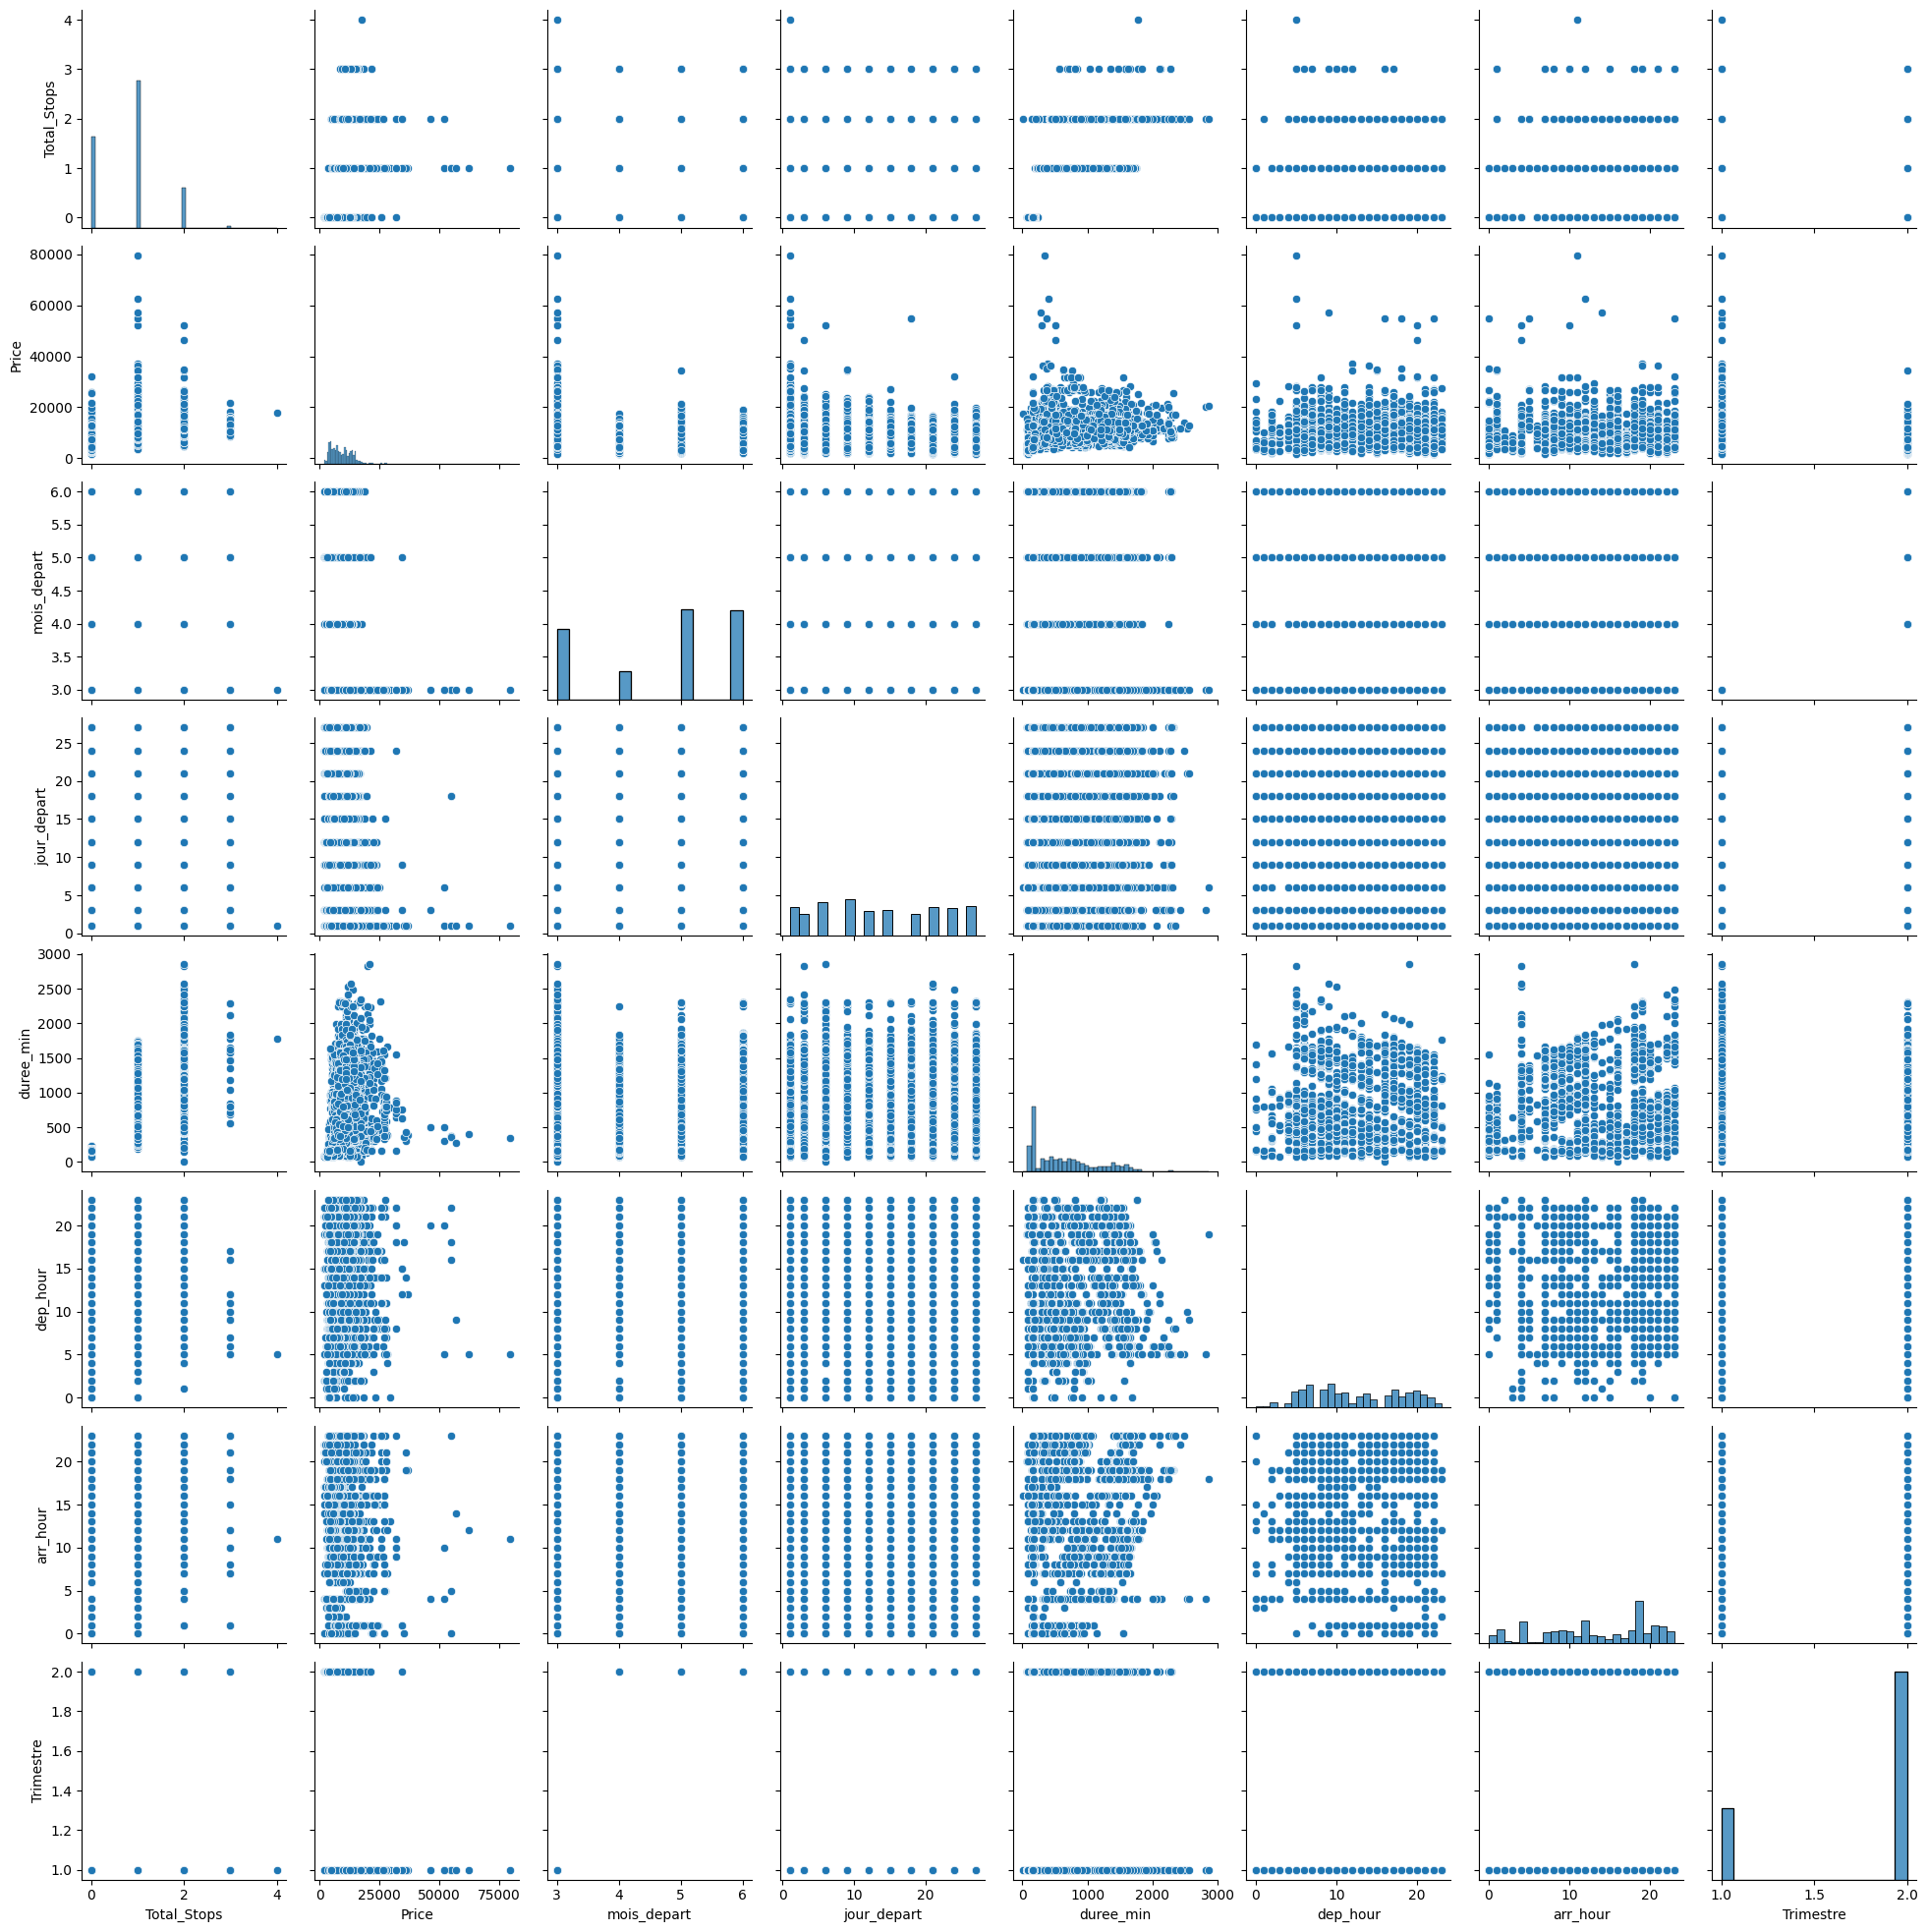

In [42]:
sns.pairplot(data_Train)

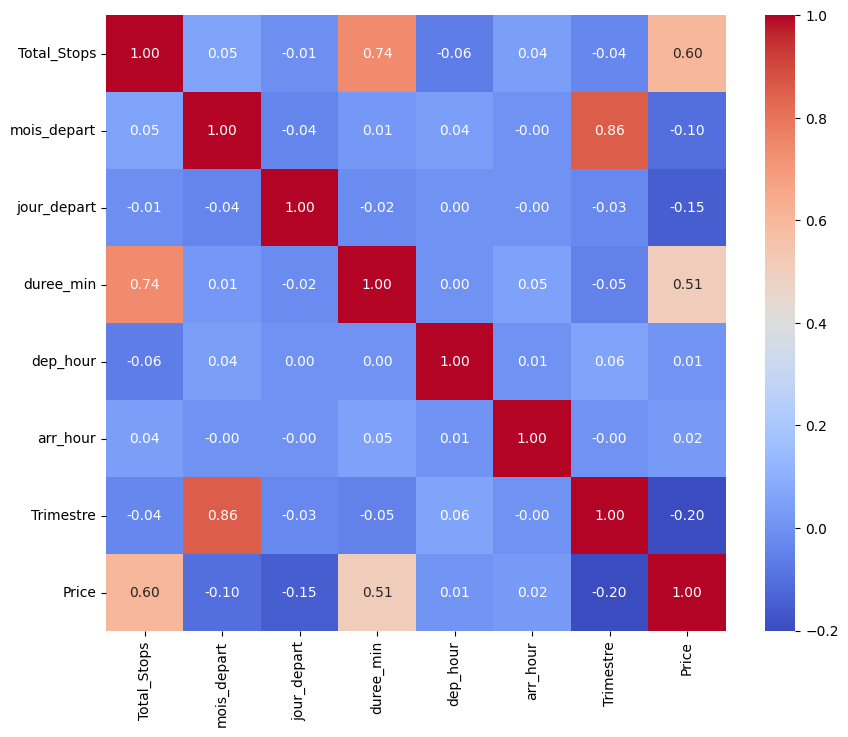

In [43]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Sélection des variables numériques (sans la cible)
features = data_Train.drop('Price', axis=1).select_dtypes(include=['number'])

# 2. Standardisation
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 3. Transformer en DataFrame avec les mêmes noms de colonnes
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns, index=features.index)

# 4. Ajouter la colonne Price si tu veux l’inclure pour corrélation
features_scaled_df['Price'] = data_Train['Price']

# 5. Maintenant tu peux faire ta corrélation
corr_matrix = features_scaled_df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [44]:
data=data_Train.groupby("Trimestre")["Trimestre"].count()
data

Trimestre
1    2724
2    7958
Name: Trimestre, dtype: int64

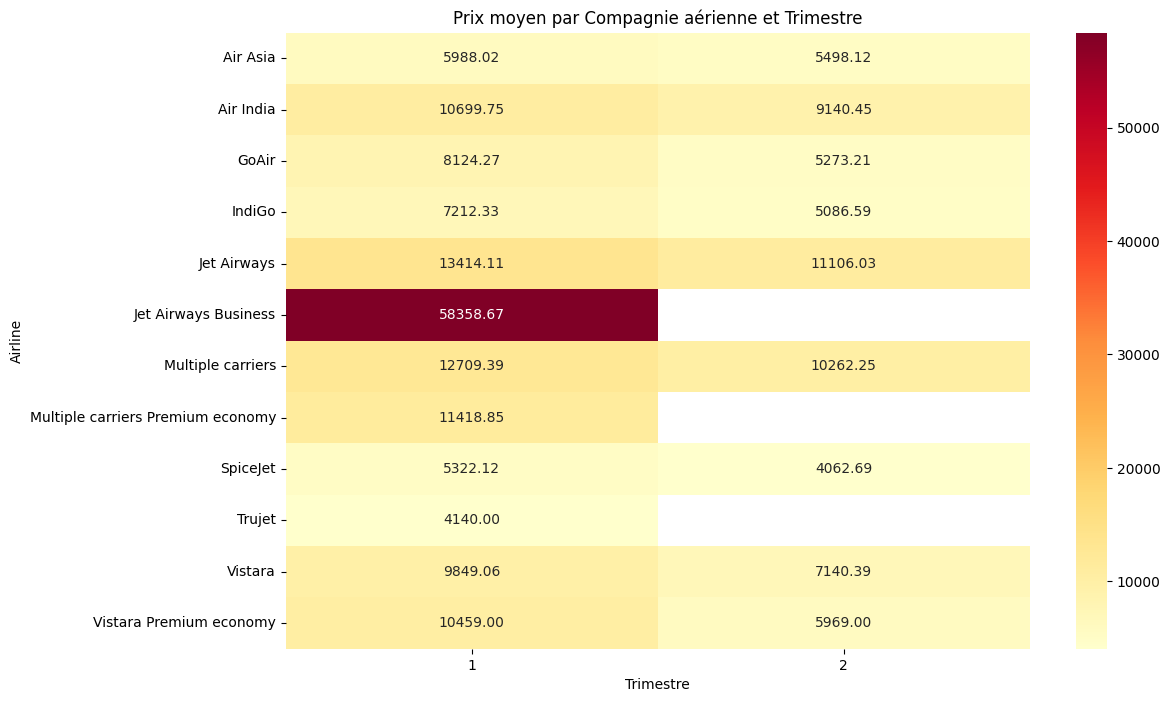

In [48]:
data1=data_Train.groupby("Trimestre")["Price"].mean()
import seaborn as sns
import matplotlib.pyplot as plt

pivot_table = data_Train.pivot_table(values='Price', index='Airline', columns='Trimestre', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title('Prix moyen par Compagnie aérienne et Trimestre')
plt.ylabel('Airline')
plt.xlabel('Trimestre')
plt.show()

<Axes: xlabel='mois_depart', ylabel='count'>

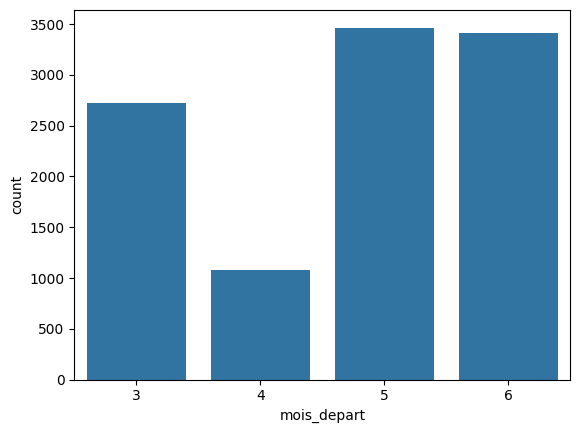

In [46]:
data2 = data_Train.groupby("mois_depart")["mois_depart"].count().reset_index(name='count')
data2
sns.barplot(x=data2["mois_depart"],y=data2["count"])

C:\Users\landr\AppData\Local\Temp\ipykernel_34592\78937325.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(y=data2["mois_depart"], x=data2["count"],orient='h',palette='viridis')


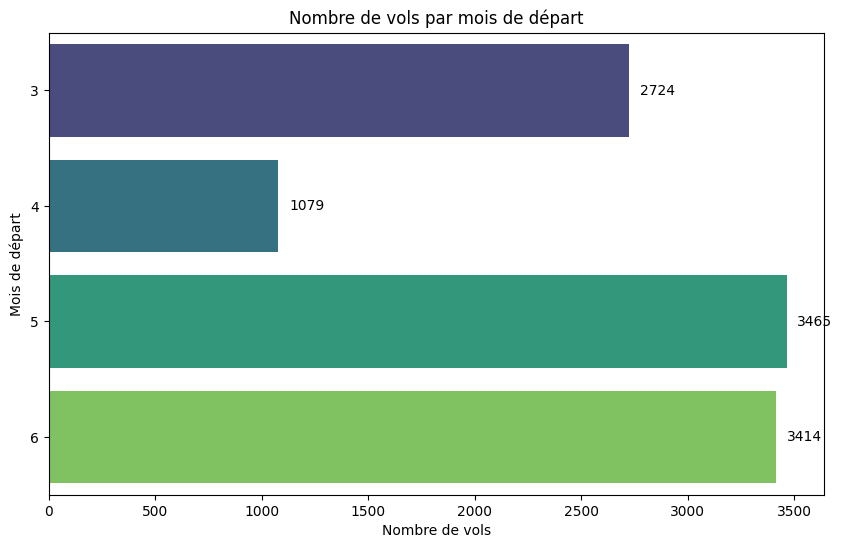

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
barplot = sns.barplot(y=data2["mois_depart"], x=data2["count"],orient='h',palette='viridis')

plt.xlabel('Nombre de vols')
plt.ylabel('Mois de départ')
plt.title('Nombre de vols par mois de départ')

# Ajouter les valeurs au bout des barres
for index, value in enumerate(data2["count"]):
    barplot.text(value + 50, index, str(value), va='center')

plt.show()

In [58]:
mean_price_by_stops = data_Train.groupby('Total_Stops')['Price'].mean().reset_index()
mean_price_by_stops

,Total_Stops,Price
0,0,5024.900315
1,1,10594.123556
2,2,12715.807895
3,3,13112.000000
4,4,17686.000000


C:\Users\landr\AppData\Local\Temp\ipykernel_34592\4282651315.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mean_price_by_stops, x='Total_Stops', y='Price', palette='coolwarm')


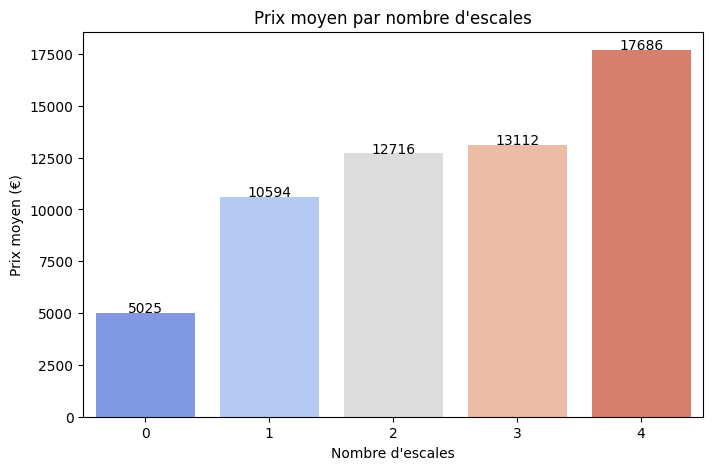

In [59]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=mean_price_by_stops, x='Total_Stops', y='Price', palette='coolwarm')

# Ajouter les valeurs
for i, value in enumerate(mean_price_by_stops['Price']):
    ax.text(i, value + 10, f'{value:.0f}', ha='center')

plt.xlabel('Nombre d\'escales')
plt.ylabel('Prix moyen (€)')
plt.title('Prix moyen par nombre d\'escales')
plt.show()